In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [76]:
zoonomia_447 = pd.read_csv("../output/all_TFs_cds_phyloP_zoonoma_447.csv")
display(zoonomia_447)
zoonomia_241 = pd.read_csv("../output/all_TFs_cds_phyloP.csv")
display(zoonomia_241)

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_41739/1107445535.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  zoonomia_447 = pd.read_csv("../output/all_TFs_cds_phyloP_zoonoma_447.csv")


,Unnamed: 0,0,1,2,ENST,12,PhyloP,AD,DBD
0,0,6,53128206,53128207,ENST00000259803,-1,0.738,False,False
1,1,6,53128207,53128208,ENST00000259803,-1,3.704,False,False
2,2,6,53128208,53128209,ENST00000259803,-1,2.464,True,False
3,3,6,53128209,53128210,ENST00000259803,-1,4.172,True,False
4,4,6,53128210,53128211,ENST00000259803,-1,0.772,True,False
...,...,...,...,...,...,...,...,...,...
742080,742080,19,15379726,15379727,ENST00000269701,-1,5.263,True,True
742081,742081,19,15379727,15379728,ENST00000269701,-1,7.646,True,True
742082,742082,19,15379728,15379729,ENST00000269701,-1,7.646,False,True
742083,742083,19,15379729,15379730,ENST00000269701,-1,6.913,False,True


/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_41739/1107445535.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  zoonomia_241 = pd.read_csv("../output/all_TFs_cds_phyloP.csv")


,Unnamed: 0,0,1,2,ENST,12,PhyloP,AD,DBD
0,0,6,53128206,53128207,ENST00000259803,-1,3.506,False,False
1,1,6,53128207,53128208,ENST00000259803,-1,4.649,False,False
2,2,6,53128208,53128209,ENST00000259803,-1,1.790,True,False
3,3,6,53128209,53128210,ENST00000259803,-1,5.710,True,False
4,4,6,53128210,53128211,ENST00000259803,-1,0.398,True,False
...,...,...,...,...,...,...,...,...,...
745444,745444,19,15379727,15379728,ENST00000269701,-1,8.697,True,True
745445,745445,19,15379728,15379729,ENST00000269701,-1,8.697,False,True
745446,745446,19,15379729,15379730,ENST00000269701,-1,6.192,False,True
745447,745447,19,15379730,15379731,ENST00000269701,-1,6.217,False,True


In [77]:
merged_data = pd.merge(zoonomia_447, zoonomia_241, on=["0", "1", "2", "ENST", "12", "AD", "DBD"], suffixes = ("_447", "_241"))
display(merged_data)

,Unnamed: 0_447,0,1,2,ENST,12,PhyloP_447,AD,DBD,Unnamed: 0_241,PhyloP_241
0,0,6,53128206,53128207,ENST00000259803,-1,0.738,False,False,0,3.506
1,1,6,53128207,53128208,ENST00000259803,-1,3.704,False,False,1,4.649
2,2,6,53128208,53128209,ENST00000259803,-1,2.464,True,False,2,1.790
3,3,6,53128209,53128210,ENST00000259803,-1,4.172,True,False,3,5.710
4,4,6,53128210,53128211,ENST00000259803,-1,0.772,True,False,4,0.398
...,...,...,...,...,...,...,...,...,...,...,...
706326,742080,19,15379726,15379727,ENST00000269701,-1,5.263,True,True,745443,4.610
706327,742081,19,15379727,15379728,ENST00000269701,-1,7.646,True,True,745444,8.697
706328,742082,19,15379728,15379729,ENST00000269701,-1,7.646,False,True,745445,8.697
706329,742083,19,15379729,15379730,ENST00000269701,-1,6.913,False,True,745446,6.192


Text(-20, 9, 'Spearman: 0.95')

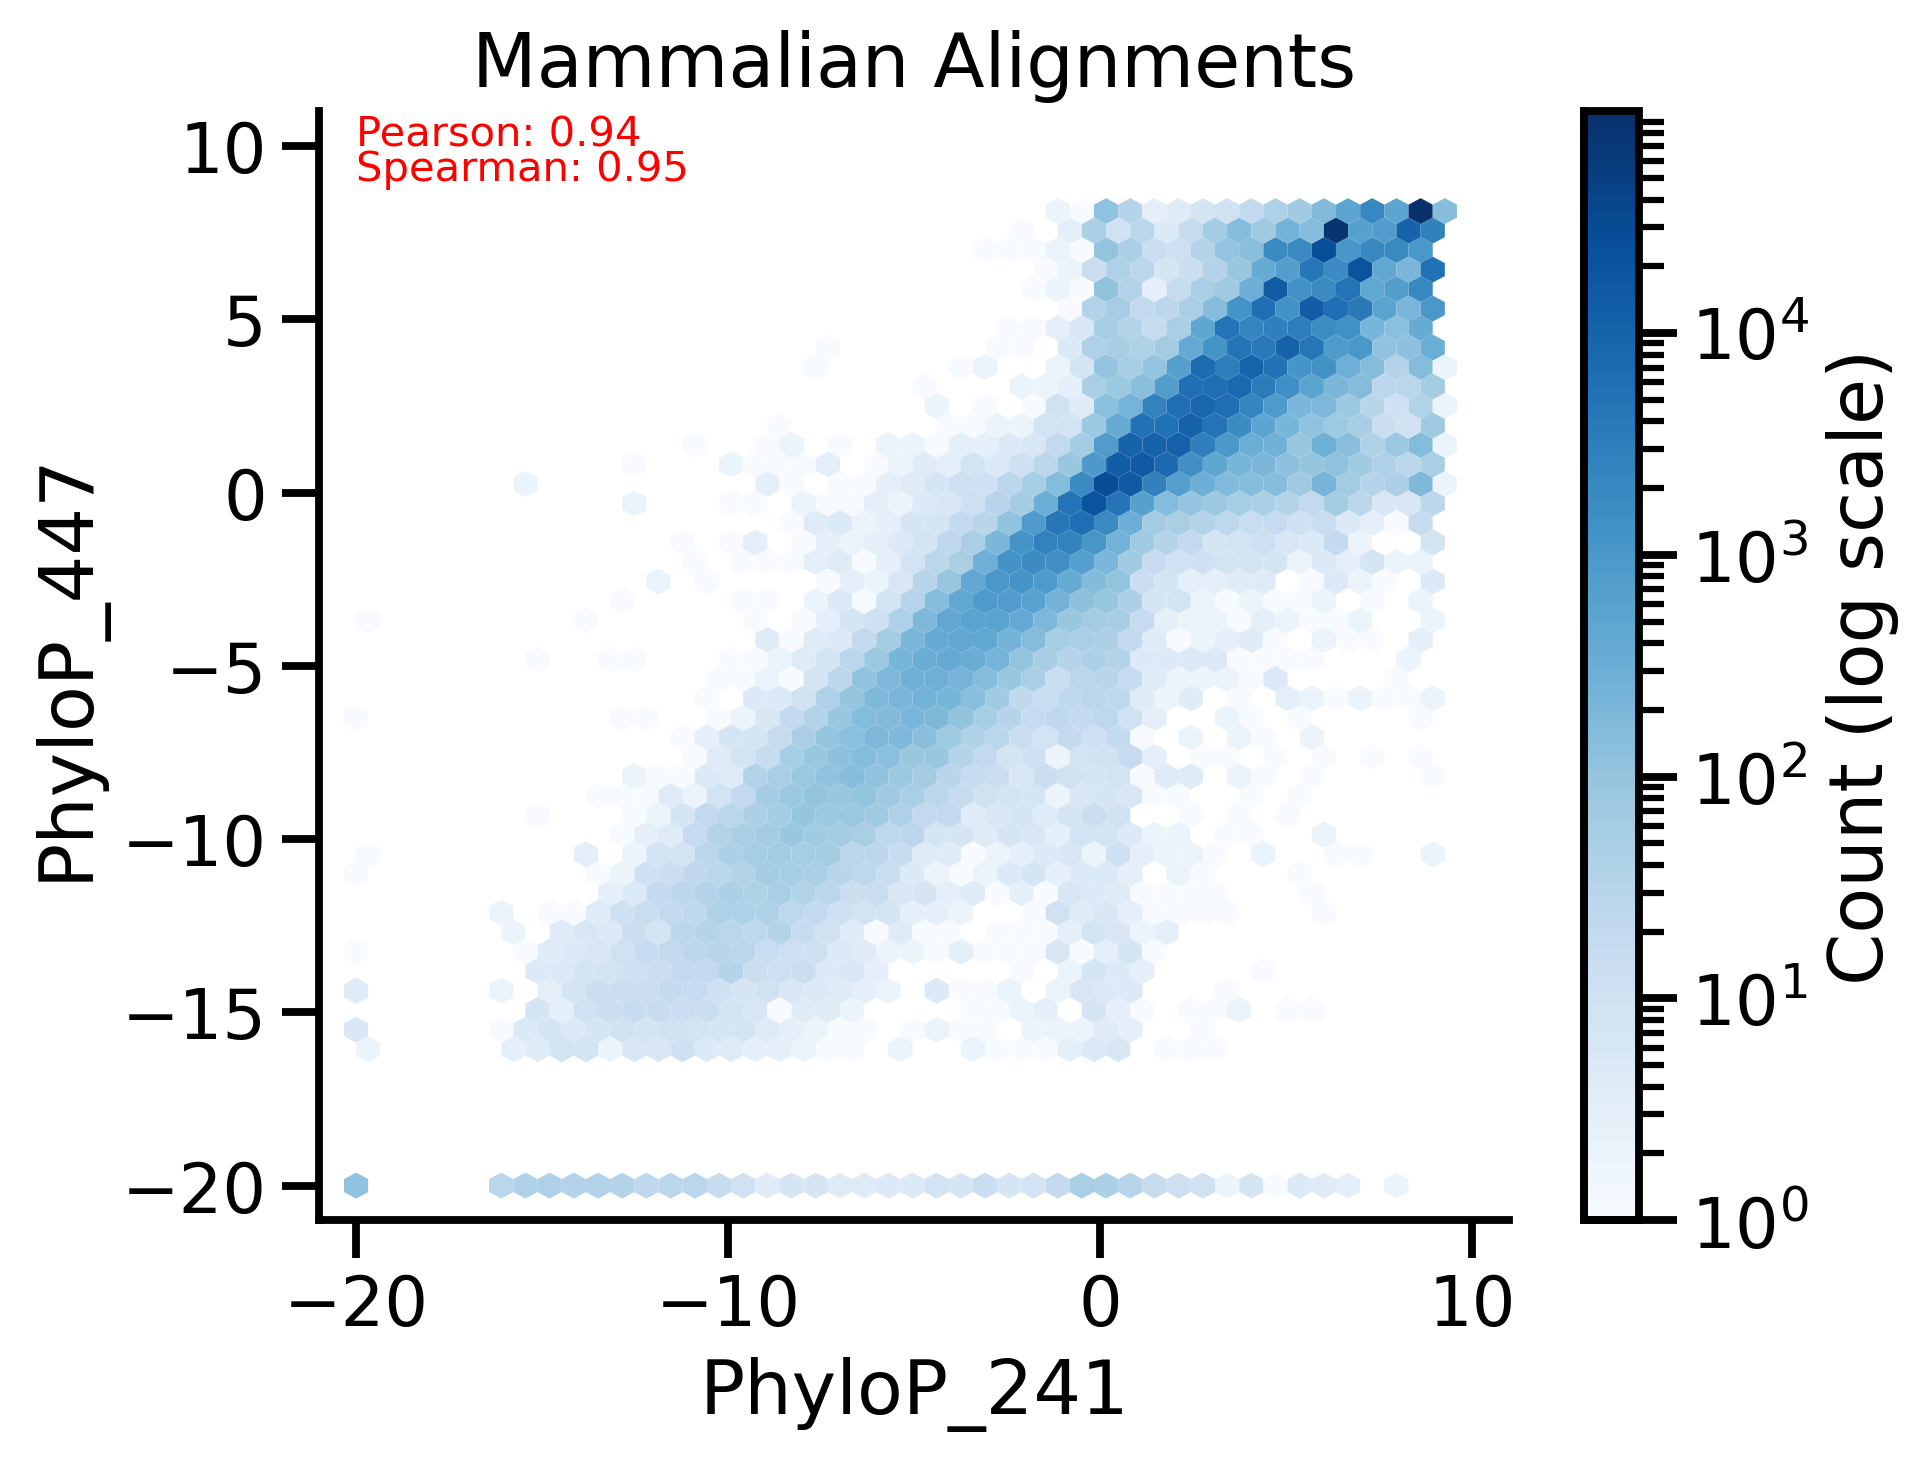

In [80]:
from scipy.stats import pearsonr, spearmanr

# Calculate Pearson and Spearman correlations
pearson_corr, _ = pearsonr(merged_data["PhyloP_241"], merged_data["PhyloP_447"])
spearman_corr, _ = spearmanr(merged_data["PhyloP_241"], merged_data["PhyloP_447"])

# Plot the hexbin
from matplotlib.colors import LogNorm

sns.set_context('talk')
plt.figure(dpi=300)
plt.hexbin(x=merged_data["PhyloP_241"], y=merged_data["PhyloP_447"], gridsize=45, cmap='Blues', norm=LogNorm(), linewidths=0)
plt.colorbar(label='Count (log scale)')
plt.xlabel("PhyloP_241")
plt.ylabel("PhyloP_447")
plt.ylim(-21, 11)
plt.xlim(-21, 11)
sns.despine()
plt.title("Mammalian Alignments")

# Add correlation coefficients as text
plt.text(-20, 10, f"Pearson: {pearson_corr:.2f}", fontsize=10, color='red')
plt.text(-20, 9, f"Spearman: {spearman_corr:.2f}", fontsize=10, color='red')

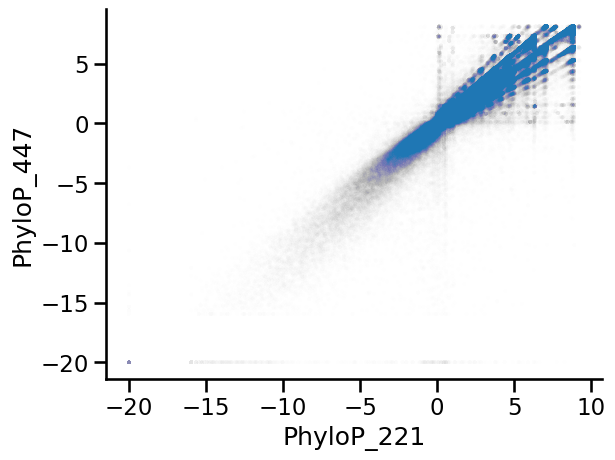

In [30]:
sns.set_context('talk')
ax = sns.scatterplot(data = merged_data, x = "PhyloP_221", y = "PhyloP_447", s = 10, alpha = 0.005, edgecolor = 'none')
sns.despine()